In [1]:
!pip install renom-q

     |████████████████████████████████| 52 kB 826 kB/s 


In [2]:
from renom_q import *
from renom_q.ml.qpca import QPCA
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
from matplotlib import rc

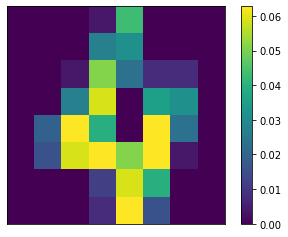

In [3]:
images = load_digits()
mnist_image = images.images[4]

mnist_image = mnist_image/255

plt.imshow(mnist_image)
plt.colorbar()
plt.tick_params(bottom=False, left=False)
plt.tick_params(labelbottom=False, labelleft=False)
plt.show()

Example1: In the case of using Nelder-Mead method 
The argument steps of QPCA.fit is the number of optimal solution searches in the Nelder-Mead method. If not specified, the number of optimal solution searches is steps=50 .

In [4]:
n_components = 6
qpca = QPCA(n_components=n_components)
qpca.fit(mnist_image, method='Nelder-Mead', steps=10)

In [5]:
print(qpca.eigenvalue)
print()
print(qpca.components_)

[0.001136439921735769, 0.0005467737519755768, 0.0008311363165856774, 4.877227432435923e-05, 0.0002110233347410427, 0.0001231205543482801]

[[-1.24099194e-01 -1.07013592e-01 -7.33822969e-01 -6.32792438e-01
  -1.95922478e-02 -2.38273247e-02 -1.15852819e-01 -1.40895663e-01]
 [ 1.54134335e-01 -2.25025131e-01 -2.90321371e-02  4.23848486e-02
  -5.56366633e-01 -7.62758168e-01  1.04795031e-01  1.43670129e-01]
 [ 4.90497373e-03  1.68865687e-02 -1.67084504e-03 -5.75229167e-03
   7.78006836e-01 -5.38909321e-01 -2.65022594e-01  1.83575696e-01]
 [ 6.86269541e-02  1.37433619e-01  4.57673278e-02  9.16545044e-02
   1.87122027e-03 -8.17653542e-01  1.24791713e-03 -5.45293290e-01]
 [ 1.05929040e-01 -1.11879300e-01 -6.78881902e-01  7.17016149e-01
  -5.49246416e-03  3.02255571e-05  3.52003050e-02 -1.93710655e-04]
 [ 1.80507714e-01  1.59073749e-01  6.06081382e-01  5.34113670e-01
  -9.97220219e-02 -1.16800604e-01 -3.34831457e-01 -3.92175325e-01]]


sudo: aptitude: command not found
Reading package lists... Done
Building dependency tree       
Reading state information... Done
dvipng is already the newest version (1.15-1).
The following package was automatically installed and is no longer required:
  libnvidia-common-460
Use 'sudo apt autoremove' to remove it.
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
Reading package lists... Done
Building dependency tree       
Reading state information... Done
dvipng is already the newest version (1.15-1).
texlive is already the newest version (2017.20180305-1).
texlive-fonts-recommended is already the newest version (2017.20180305-1).
texlive-latex-extra is already the newest version (2017.20180305-2).
The following package was automatically installed and is no longer required:
  libnvidia-common-460
Use 'sudo apt autoremove' to remove it.
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
Reading package lists... Done
Building dependency tree       
Reading s

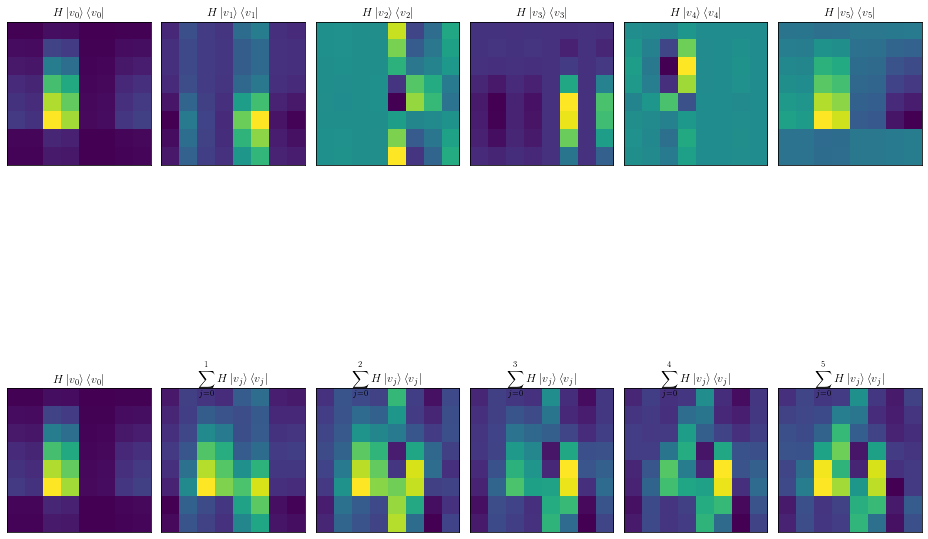

In [9]:
!sudo aptitude install texlive-fonts-recommended texlive-fonts-extra
!sudo apt-get install dvipng
!sudo apt install texlive texlive-latex-extra texlive-fonts-recommended dvipng
!pip install latex
! sudo apt-get install texlive-latex-recommended 
! sudo apt-get install dvipng texlive-latex-extra texlive-fonts-recommended  
! wget http://mirrors.ctan.org/macros/latex/contrib/type1cm.zip 
! unzip type1cm.zip -d /tmp/type1cm 
! cd /tmp/type1cm/type1cm/ && sudo latex type1cm.ins
! sudo mkdir /usr/share/texmf/tex/latex/type1cm 
! sudo cp /tmp/type1cm/type1cm/type1cm.sty /usr/share/texmf/tex/latex/type1cm 
! sudo texhash 

!apt install cm-super

num = n_components

size = int(np.log2(mnist_image.shape[0]))
eigenvector_image = []
eigenvector_sum_image = [np.zeros((2**size, 2**size)) for i in range(num)]

for i in range(num):
    vec = np.outer(qpca.components_[i], qpca.components_[i])
    array = np.dot(mnist_image, vec)
    eigenvector_image.append(array)
    for j in range(num-i):
        eigenvector_sum_image[num-1-j] += array

rc('text', usetex=True)
title = []
for i in range(num):
    title.append(r'$H \left| v_'+str(i)+r' \right\rangle \left\langle v_'+str(i)+r' \right|$')
title.append(r'$H \left| v_0 \right\rangle \left\langle v_0 \right|$')
for i in range(num-1):
    title.append(r'$\displaystyle \sum^'+str(i+1)+r'_{j=0} H \left| v_j \right\rangle \left\langle v_j \right|$')

fig = plt.figure(figsize=(13,13))

for i in range(2*num):
    plt.subplot(2, num, i+1)
    if i < num:
        plt.imshow(eigenvector_image[i])
    else:
        plt.imshow(eigenvector_sum_image[i-num])
    plt.title(title[i])
    plt.tick_params(bottom=False, left=False)
    plt.tick_params(labelbottom=False, labelleft=False)

fig.tight_layout()
plt.show()

Example2: In the case of using QPSO method 
The argument n_particle of QPCA.fit is the number of particles in QPSO method. If not specified, the number of particles is n_particle=100 . The argument steps of QPCA.fit is the number of optimal solution searches in QPSO method. If not specified, the number of optimal solution searches is steps=50 .

In [10]:
n_components = 6
qpca = QPCA(n_components=n_components)
qpca.fit(mnist_image, method='QPSO', n_particle=80, steps=20)

In [11]:
print(qpca.eigenvalue)
print()
print(qpca.components_)

[0.0011375516574875888, 0.0008275617181139379, 0.0005298492465507609, 0.0002355887012204283, 8.952934095509744e-05, 0.00010725184780336898]

[[ 1.08751694e-01  8.39078972e-02  7.75100328e-01  5.98032419e-01
   1.54903192e-02  1.40880121e-02  1.10403351e-01  1.00408761e-01]
 [-3.52480295e-03 -1.18056230e-02  1.07124702e-03  3.58792779e-03
   7.68711051e-01 -5.69540229e-01 -2.33624243e-01  1.73092874e-01]
 [ 9.14546015e-03  1.23773998e-02 -1.06084683e-03 -1.43574245e-03
   5.39318744e-01  8.34039429e-01 -6.25594086e-02 -9.67461525e-02]
 [-1.54278076e-01  1.97583546e-01  5.89403442e-01 -7.54847511e-01
   3.57743437e-02 -7.48905989e-04 -1.36672182e-01  2.86111791e-03]
 [-4.60648882e-01  1.71268417e-01  3.95205652e-01 -1.46936743e-01
  -5.67653020e-01 -1.10727868e-01  4.87007982e-01  9.49970382e-02]
 [-3.84276474e-02 -1.26141682e-01 -2.17655285e-01 -7.14470069e-01
   1.12581240e-01 -1.28720567e-02  6.37663337e-01 -7.29076947e-02]]


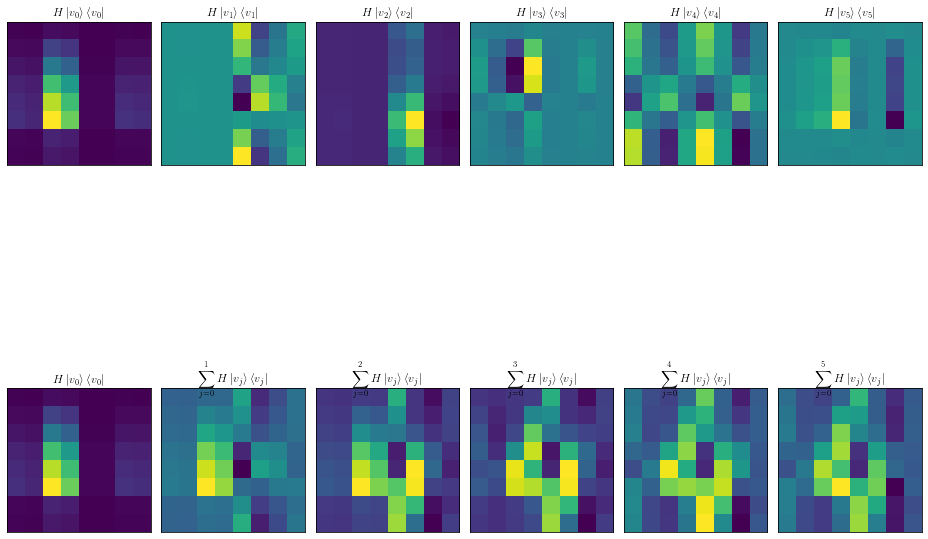

In [12]:
num = n_components

size = int(np.log2(mnist_image.shape[0]))
eigenvector_image = []
eigenvector_sum_image = [np.zeros((2**size, 2**size)) for i in range(num)]

for i in range(num):
    vec = np.outer(qpca.components_[i], qpca.components_[i])
    array = np.dot(mnist_image, vec)
    eigenvector_image.append(array)
    for j in range(num-i):
        eigenvector_sum_image[num-1-j] += array

rc('text', usetex=True)
title = []
for i in range(num):
    title.append(r'$H \left| v_'+str(i)+r' \right\rangle \left\langle v_'+str(i)+r' \right|$')
title.append(r'$H \left| v_0 \right\rangle \left\langle v_0 \right|$')
for i in range(num-1):
    title.append(r'$\displaystyle \sum^'+str(i+1)+r'_{j=0} H \left| v_j \right\rangle \left\langle v_j \right|$')

fig = plt.figure(figsize=(13,13))

for i in range(2*num):
    plt.subplot(2, num, i+1)
    if i < num:
        plt.imshow(eigenvector_image[i])
    else:
        plt.imshow(eigenvector_sum_image[i-num])
    plt.title(title[i])
    plt.tick_params(bottom=False, left=False)
    plt.tick_params(labelbottom=False, labelleft=False)

fig.tight_layout()
plt.show()

In [13]:
print(qpca.mean_)
print()
print(qpca.get_covariance())

[0.         0.00441176 0.01911765 0.03284314 0.03382353 0.02794118
 0.00833333 0.        ]

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  6.78310540e-05  2.11182512e-04  8.48574724e-05
  -5.62970286e-05  1.75481957e-04  3.26797386e-05  0.00000000e+00]
 [ 0.00000000e+00  2.11182512e-04  7.48887790e-04  4.20442687e-04
  -2.97413083e-04  6.22013511e-04  1.89212940e-04  0.00000000e+00]
 [ 0.00000000e+00  8.48574724e-05  4.20442687e-04  5.53358598e-04
  -3.24875048e-04  3.02356237e-04  1.74932718e-04  0.00000000e+00]
 [ 0.00000000e+00 -5.62970286e-05 -2.97413083e-04 -3.24875048e-04
   6.06085571e-04 -1.26599659e-04 -2.67204921e-04  0.00000000e+00]
 [ 0.00000000e+00  1.75481957e-04  6.22013511e-04  3.02356237e-04
  -1.26599659e-04  6.74191245e-04  1.46921514e-04  0.00000000e+00]
 [ 0.00000000e+00  3.26797386e-05  1.89212940e-04  1.74932718e-04
  -2.67204921e-04  1.46921514e-04  1.5131542